# Predicting Educational Video Engagement with Supervised Machine Learning

This notebook builds a supervised machine learning workflow to predict whether educational videos are likely to generate high viewer engagement. The project is based on the following tabular video-level features: title_word_count, document_entropy, freshness, easiness, fraction_stopword_presence, speaker_speed and silent_period_rate (more information in 2. Data Loading)


## 1. Setup

The main libraries used are pandas and NumPy for data handling, matplotlib for plotting, and scikit-learn for preprocessing, model training, model selection, and evaluation.

A fixed random seed is used where applicable to make the workflow more reproducible.


In [ ]:
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.calibration import CalibratedClassifierCV

np.random.seed(0)
RANDOM_STATE = 42


## 2. Data Loading

The notebook uses two preprocessed CSV files:

- `train.csv`, containing features and the target label
- `test.csv`, containing the same features for unseen videos, excluding the target label

The CSV files provided in the `data/` folder are derived from the public `VLE dataset` created by sahanbull, available here `https://github.com/sahanbull/VLE-Dataset`.

In [4]:
DATA_BASE_URL = "data"

train_data = pd.read_csv(f"{DATA_BASE_URL}/train.csv")
test_data = pd.read_csv(f"{DATA_BASE_URL}/test.csv")

X = train_data.iloc[:, :-1]
y = train_data.iloc[:, -1]

train_data.head()


,id,title_word_count,document_entropy,freshness,easiness,fraction_stopword_presence,normalization_rate,speaker_speed,silent_period_rate,engagement
0,1,9,7.753995,16310,75.583936,0.553664,0.034049,2.997753,0.0,True
1,2,6,8.305269,15410,86.870523,0.584498,0.018763,2.635789,0.0,False
2,3,3,7.965583,15680,81.915968,0.605685,0.030720,2.538095,0.0,False
3,4,9,8.142877,15610,80.148937,0.593664,0.016873,2.259055,0.0,False
4,5,9,8.161250,14920,76.907549,0.581637,0.023412,2.420000,0.0,False


## 3. Exploratory Data Checks

Before modelling, I check for overlap between the training and test video IDs, inspect the class distribution, and review the feature ranges.

The class distribution is imbalanced, with the negative class making up most of the training examples. The feature summaries also show that variables are on different numeric scales, which matters for models such as logistic regression and SVMs. For those models I will do scaling inside a pipeline.


In [5]:
# Check whether any video IDs appear in both train and test data
has_overlap = train_data["id"].isin(test_data["id"]).any()
print(f"Is there overlap between train and test IDs? {has_overlap}")

# Inspect target distribution
print("\nTarget distribution:")
print(y.value_counts())

# Inspect feature ranges and central tendency
traits_df = X.describe().T[["max", "min", "mean", "50%"]]
traits_df


Is there overlap between train and test IDs? False

Target distribution:
engagement
False    8342
True      897
Name: count, dtype: int64


,max,min,mean,50%
id,9239.000000,1.000000,4620.000000,4620.000000
title_word_count,33.000000,1.000000,7.701050,7.000000
document_entropy,9.278573,0.000000,7.792685,7.875103
freshness,17430.000000,10830.000000,14808.587509,14750.000000
easiness,122.032000,28.210966,84.756029,84.482122
fraction_stopword_presence,1.000000,0.000000,0.612214,0.613127
normalization_rate,0.101990,0.000000,0.021354,0.019843
speaker_speed,50.850000,0.000302,2.413320,2.267133
silent_period_rate,1.168239,0.000000,0.146606,0.104915


## 4. Train/Validation Split

The training data is split into a training subset and a validation subset. Because the target is imbalanced, I use a stratified split so the class proportions are preserved in both subsets.


In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)


Training shape: (6929, 9)
Validation shape: (2310, 9)


## 5. Feature Importance Check with a Decision Tree

A decision tree is used as a quick exploratory model to inspect feature importances (Trees do not require feature scaling because they split on feature thresholds directly)

The `id` feature is included in this exploratory step to check whether it appears to encode information. This was done mostly out of curiosity as it is an identifier rather than a meaningful video property, and including identifier columns can sometimes create misleading patterns. At this depth, it does not appear to be an important predictor.


Accuracy of Decision Tree classifier on training set: 0.94
Accuracy of Decision Tree classifier on validation set: 0.93


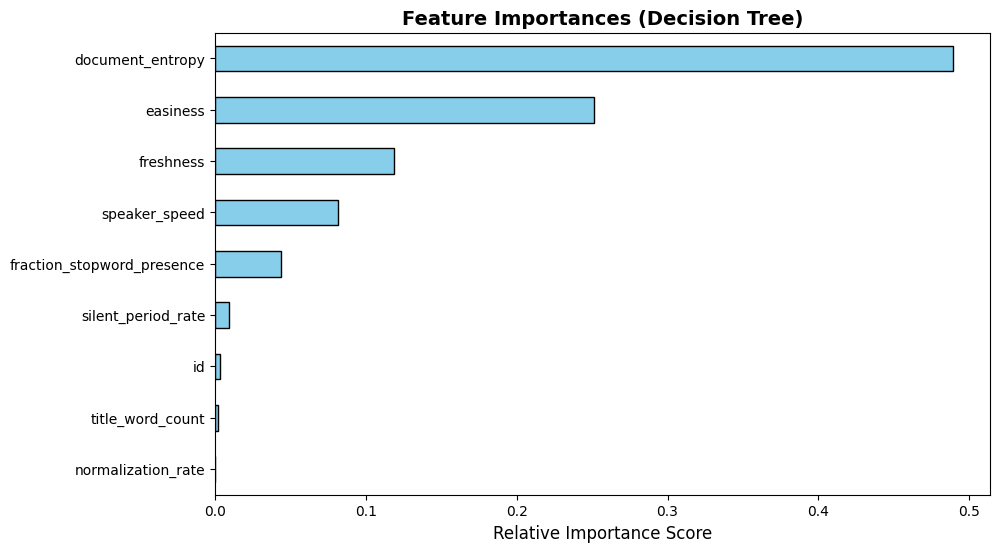

In [7]:
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
tree_clf.fit(X_train, y_train)

print("Accuracy of Decision Tree classifier on training set: {:.2f}".format(tree_clf.score(X_train, y_train)))
print("Accuracy of Decision Tree classifier on validation set: {:.2f}".format(tree_clf.score(X_val, y_val)))

feat_importances = pd.Series(tree_clf.feature_importances_, index=X_train.columns)
feat_importances = feat_importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_importances.plot(kind="barh", color="skyblue", edgecolor="black")
plt.title("Feature Importances (Decision Tree)", fontsize=14, fontweight="bold")
plt.xlabel("Relative Importance Score", fontsize=12)
plt.show()


Id is removed below.

In [8]:
X_train = X_train.iloc[:, 1:]
X_val = X_val.iloc[:, 1:]

print("Training shape after removing id:", X_train.shape)
print("Validation shape after removing id:", X_val.shape)


Training shape after removing id: (6929, 8)
Validation shape after removing id: (2310, 8)


## 6. Model Selection with Pipelines

I compare Logistic Regression and SVM models using scikit-learn pipelines. The pipeline ensures that feature scaling is fitted only on the training folds during cross-validation, reducing the risk of data leakage.

ROC AUC is used as the model-selection metric because the dataset is imbalanced and accuracy could be misleading. A classifier could achieve strong accuracy by mostly predicting the majority class (seen below with the DummyClassifier), while still performing poorly on the high-engagement class. ROC AUC measures how well the model ranks high-engagement examples above low-engagement examples across different thresholds, making it more appropriate for evaluating the model’s ability to distinguish between the two classes.


In [9]:
# Logistic Regression

start_time = time.time()

pipe_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

param_grid_logreg = {
    "model__C": [0.1, 1, 10],
}

grid_logreg = GridSearchCV(
    pipe_logreg,
    param_grid=param_grid_logreg,
    cv=5,
    scoring="roc_auc"
)

grid_logreg.fit(X_train, y_train)

end_time = time.time()

print("Took {:.3f} seconds".format(end_time - start_time))
print("Best Logistic Regression C: {:.3f}".format(grid_logreg.best_params_["model__C"]))
print("Best Logistic Regression ROC AUC: {:.3f}".format(grid_logreg.best_score_))


Took 0.306 seconds
Best Logistic Regression C: 0.100
Best Logistic Regression ROC AUC: 0.844


In [10]:
# Balanced SVM

start_time = time.time()

pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(class_weight="balanced", random_state=RANDOM_STATE))
])

param_grid_svm = {
    "model__C": [0.1, 1, 10],
    "model__gamma": [0.01, 0.1, 1],
    "model__kernel": ["rbf"]
}

grid_svm = GridSearchCV(
    pipe_svm,
    param_grid=param_grid_svm,
    cv=5,
    scoring="roc_auc"
)

grid_svm.fit(X_train, y_train)

end_time = time.time()

print("Took {:.3f} seconds".format(end_time - start_time))
print("Best SVM C: {:.3f}".format(grid_svm.best_params_["model__C"]))
print("Best SVM gamma: {:.3f}".format(grid_svm.best_params_["model__gamma"]))
print("Best SVM ROC AUC: {:.3f}".format(grid_svm.best_score_))


Took 43.929 seconds
Best SVM C: 1.000
Best SVM gamma: 0.100
Best SVM ROC AUC: 0.870


## 7. Validation Set Evaluation

A dummy classifier provides a baseline to show how much value the supervised models add beyond a naive prediction strategy.

The validation results compare accuracy, precision, recall, F1 score, and ROC AUC (For ROC AUC, I use model scores/probabilities rather than hard class predictions. This is important because ROC AUC evaluates ranking quality across thresholds)


In [11]:
y_pred_logreg = grid_logreg.predict(X_val)
y_pred_svm = grid_svm.predict(X_val)

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)

dummy_probs = dummy.predict_proba(X_val)[:, 1]
logreg_scores = grid_logreg.decision_function(X_val)
svm_scores = grid_svm.decision_function(X_val)

results = pd.DataFrame([
    {
        "model": "Dummy",
        "accuracy": accuracy_score(y_val, y_pred_dummy),
        "precision": precision_score(y_val, y_pred_dummy, zero_division=0),
        "recall": recall_score(y_val, y_pred_dummy),
        "f1": f1_score(y_val, y_pred_dummy),
        "roc_auc": roc_auc_score(y_val, dummy_probs)
    },
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_val, y_pred_logreg),
        "precision": precision_score(y_val, y_pred_logreg),
        "recall": recall_score(y_val, y_pred_logreg),
        "f1": f1_score(y_val, y_pred_logreg),
        "roc_auc": roc_auc_score(y_val, logreg_scores)
    },
    {
        "model": "Balanced SVM",
        "accuracy": accuracy_score(y_val, y_pred_svm),
        "precision": precision_score(y_val, y_pred_svm),
        "recall": recall_score(y_val, y_pred_svm),
        "f1": f1_score(y_val, y_pred_svm),
        "roc_auc": roc_auc_score(y_val, svm_scores)
    }
])

results.round(3)


,model,accuracy,precision,recall,f1,roc_auc
0,Dummy,0.903,0.000,0.000,0.000,0.500
1,Logistic Regression,0.919,0.757,0.250,0.376,0.853
2,Balanced SVM,0.874,0.420,0.795,0.549,0.902


### Interpreting the Precision-Recall Trade-off

We can clearly see the Precision-Recall Trade-off in the results table above.

The Balanced SVM improves recall substantially compared with the Logistic Regression, meaning it identifies a larger proportion of genuinely high-engagement videos. In the context of a learning platform, this could be valuable for content creators because fewer potentially high-quality videos would be missed by the model.
However, this improvement in recall comes with a trade-off: precision is lower, meaning some videos predicted as high engagement may not actually perform well. From a learner perspective, these false positives could reduce recommendation quality if lower-engagement videos are surfaced too often. 
In a production setting, the preferred balance between precision and recall would depend on the platform’s objective: prioritising creators and content discovery may favour higher recall, while prioritising learner experience may require higher precision.

For this project, ROC AUC is used as the primary model-selection metric because the goal is to assess the model’s overall ability to rank high-engagement videos above lower-engagement videos across different thresholds. The final threshold could then be adjusted later depending on whether the platform wants to prioritise recall, precision, or a balance of both.

## 8. Visual Model Evaluation

The confusion matrix shows the classification trade-off between false positives and false negatives. Because the dataset is imbalanced, the ROC curve and precision-recall curve provide additional context beyond accuracy alone.

The balanced SVM is selected as the final model because it provides the strongest validation ROC AUC and substantially improves performance over the dummy baseline.


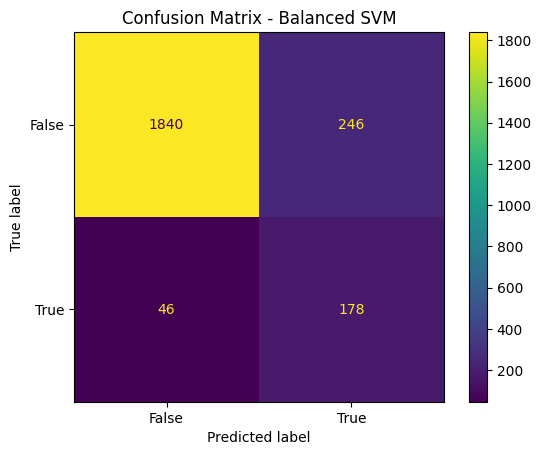

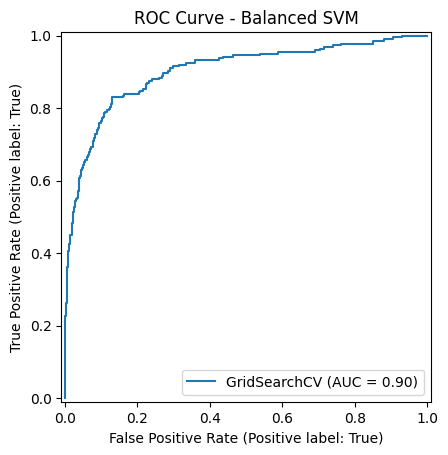

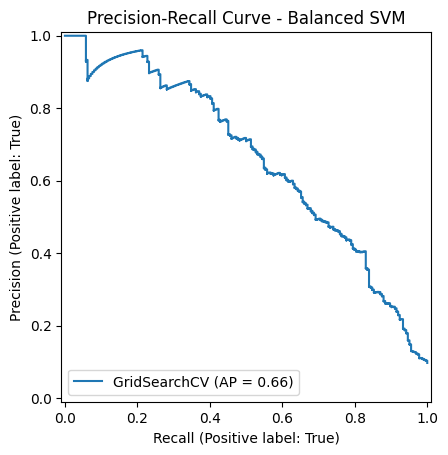

In [12]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_svm)
plt.title("Confusion Matrix - Balanced SVM")
plt.show()

RocCurveDisplay.from_estimator(grid_svm, X_val, y_val)
plt.title("ROC Curve - Balanced SVM")
plt.show()

PrecisionRecallDisplay.from_estimator(grid_svm, X_val, y_val)
plt.title("Precision-Recall Curve - Balanced SVM")
plt.show()


## 9. Final Model and Unseen Test Predictions

After selecting the final model, I retrain it on the full labelled training dataset (as we now know the best hyperparameters to use). The same feature-preparation decision is used here (the `id` column is excluded from the model inputs and retained only as the output index)

The final output is a probability score for each unseen video, indexed by video ID.


In [18]:
X_full = train_data.iloc[:, 1:-1]
y_full = train_data.iloc[:, -1]
X_test_final = test_data.iloc[:, 1:]

best_C = grid_svm.best_params_["model__C"]
best_gamma = grid_svm.best_params_["model__gamma"]

base_svc = SVC(
    class_weight="balanced",
    C=best_C,
    gamma=best_gamma,
    kernel="rbf",
    random_state=RANDOM_STATE
)

calibrated_svc = CalibratedClassifierCV(estimator=base_svc, ensemble=False)

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", calibrated_svc)
])

start_time = time.time()

final_model.fit(X_full, y_full)
test_probabilities = final_model.predict_proba(X_test_final)[:, 1]

predictions = pd.Series(
    test_probabilities,
    index=test_data["id"],
    name="predicted_engagement_probability"
)

end_time = time.time()

print("Took {:.3f} seconds".format(end_time - start_time))
predictions.head()


Took 9.705 seconds


id
9240    0.024566
9241    0.040072
9242    0.103281
9243    0.988260
9244    0.013580
Name: predicted_engagement_probability, dtype: float64

## 10. Key Takeaways

### Technical / Project Takeaways

- The target distribution is imbalanced, so accuracy alone is not sufficient for evaluating model quality. Metrics such as ROC AUC, precision, recall, F1 score, and confusion matrices provide a more complete view of performance.
- A dummy classifier provides an important baseline, helping confirm whether the supervised models are learning useful patterns rather than simply reflecting the majority class.
- Pipelines ensure that preprocessing steps such as scaling are applied safely during cross-validation, reducing the risk of data leakage.
- The Balanced SVM performed best in validation based on ROC AUC, showing stronger ranking performance than both the dummy baseline and Logistic Regression model.
- ROC AUC was useful as the main selection metric because it evaluates how well the model ranks high-engagement videos above lower-engagement videos across different thresholds.

### Business / Product Takeaways

- The final model outputs probability scores for unseen videos, which could be used to rank or prioritise content by predicted engagement.
- For a learning platform, this type of model could help identify videos that are likely to perform well, support content recommendation, or highlight promising educational material for further promotion.
- The precision-recall trade-off has practical implications. A higher-recall model reduces the chance of missing genuinely high-engagement videos, which may benefit content creators, but it may also increase false positives and surface some lower-quality recommendations to learners.
- In a production setting, the decision threshold should be chosen based on business priorities. If the goal is content discovery, higher recall may be preferred; if the goal is learner experience and recommendation quality, higher precision may be more important.